--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

--- Descriptive Statistics ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Columns after renaming: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']


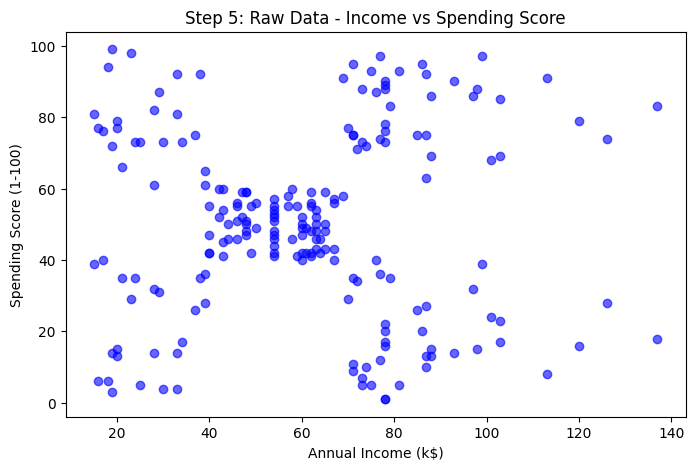


First 5 rows of Feature Matrix X:
 [[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


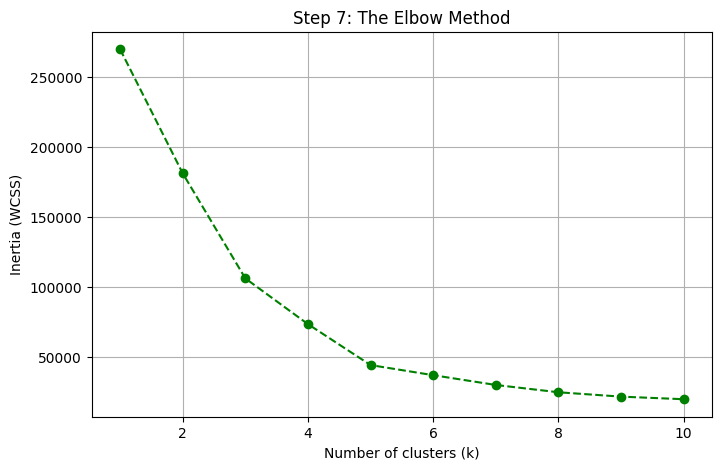


--- Cluster Analysis ---
Counts per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Mean Income and Spending Score per cluster:


,AnnualIncome,SpendingScore
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


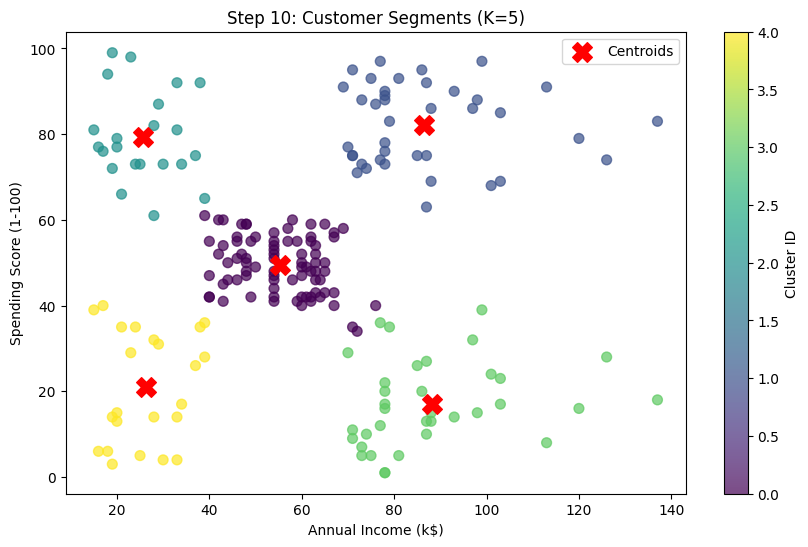

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# Steps 1 & 2: Load the dataset
# ==========================================
df = pd.read_csv('Mall_Customers.csv')

# ==========================================
# Step 3: Exploration
# ==========================================
print("--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
# display() renders nicely formatted tables in Jupyter
display(df.describe()) 

# ==========================================
# Step 4: Rename columns
# ==========================================
df = df.rename(columns={
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})
print("\nColumns after renaming:", df.columns.tolist())

# ==========================================
# Step 5: First visualization
# ==========================================
plt.figure(figsize=(8, 5))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], alpha=0.6, c='blue')
plt.title("Step 5: Raw Data - Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

# ==========================================
# Step 6: Build feature matrix X
# ==========================================
X = df.loc[:, ["AnnualIncome", "SpendingScore"]].values
print("\nFirst 5 rows of Feature Matrix X:\n", X[:5])

# ==========================================
# Step 7: Elbow method
# ==========================================
inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 suppresses warnings, random_state=42 ensures reproducibility
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='green')
plt.title('Step 7: The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

# ==========================================
# Step 8: Train K-Means with k=5
# ==========================================
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans5.fit_predict(X)

# ==========================================
# Step 9: Add labels and analyze segments
# ==========================================
df['Cluster'] = labels

print("\n--- Cluster Analysis ---")
print("Counts per cluster:")
print(df['Cluster'].value_counts().sort_index())

print("\nMean Income and Spending Score per cluster:")
display(df.groupby('Cluster')[['AnnualIncome', 'SpendingScore']].mean())

# ==========================================
# Step 10: Visualize clusters
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the 5 clusters with a color map
scatter = plt.scatter(df['AnnualIncome'], df['SpendingScore'], 
                      c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)

# Plot the center of each cluster (Centroids)
plt.scatter(kmeans5.cluster_centers_[:, 0], kmeans5.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Centroids')

plt.title('Step 10: Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.colorbar(scatter, label='Cluster ID')
plt.show()